Logistic regression accuracy: 41.67%   (kỳ vọng quanh 50%)
CustomANN(
  (layer1): Linear(in_features=2, out_features=8, bias=True)
  (relu): ReLU()
  (layer2): Linear(in_features=8, out_features=6, bias=True)
  (relu2): ReLU()
  (layer3): Linear(in_features=6, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)
Epoch  100/500  loss=0.0166  test_acc=100.00%
Epoch  200/500  loss=0.0012  test_acc=100.00%
Epoch  300/500  loss=0.0005  test_acc=100.00%
Epoch  400/500  loss=0.0003  test_acc=100.00%
Epoch  500/500  loss=0.0002  test_acc=100.00%


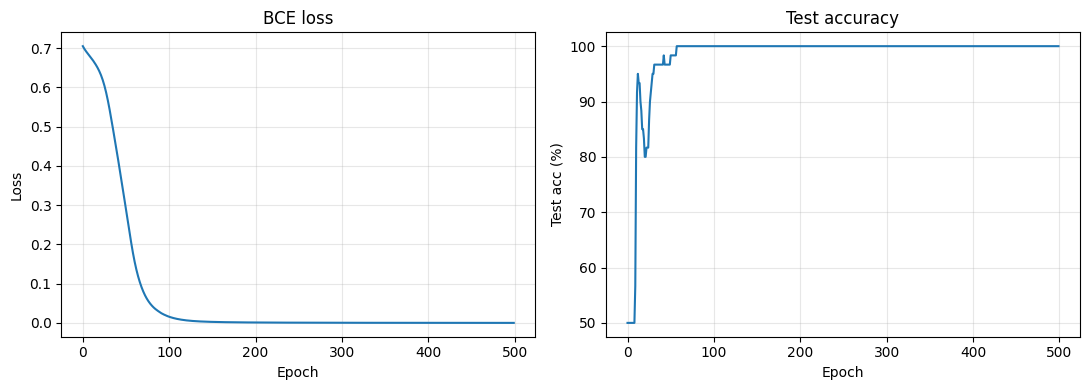

ANN final test accuracy: 100.00%
(Baseline LogReg đạt 41.67% — ANN thắng đậm vì học được ranh giới phi tuyến.)


In [21]:
#Phần 1: Thay đổi cấu trúc ANN
#1.Tăng số nút ẩn: đổi lớp ẩn từ 4 nút thành 8 nút. Train 500 epoch. Ghi loss cuối, test accuracy.
#2.Thêm một lớp ẩn: kiến trúc 2 → 8 (ReLU) → 6 (ReLU) → 1 (Sigmoid). Train 500 epoch.
#3.So sánh 3 mô hình (4 nút / 8 nút / 8+6 nút) trên cùng đồ thị loss. Câu hỏi:
#Mô hình to hơn có giảm loss nhanh hơn không? Có overfitting không?
#Có hiện tượng diminishing returns (thêm nút không giúp thêm) không?
#Gợi ý: viết hàm train(model, epochs) trả về (loss_history, acc_history) để gọi 3 lần cho gọn.

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

logreg = nn.Sequential(nn.Linear(2, 1), nn.Sigmoid())
opt_lr = optim.Adam(logreg.parameters(), lr=0.05)
for _ in range(300):
    opt_lr.zero_grad()
    loss = nn.BCELoss()(logreg(X_train), y_train)
    loss.backward(); opt_lr.step()

with torch.no_grad():
    pred = (logreg(X_test) > 0.5).float()
    acc_lr = (pred == y_test).float().mean().item()
print(f'Logistic regression accuracy: {acc_lr*100:.2f}%   (kỳ vọng quanh 50%)')
#Kiến trúc: 2 → 4 (ReLU) → 1 (Sigmoid).
class ANN(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(2, 8)
        self.relu   = nn.ReLU()
        self.layer2 = nn.Linear(8, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        return self.sigmoid(self.layer2(self.relu(self.layer1(x))))
#2.Thêm một lớp ẩn: kiến trúc 2 → 8 (ReLU) → 6 (ReLU) → 1 (Sigmoid). Train 500 epoch.
class CustomANN(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(2, 8)
        self.relu   = nn.ReLU()
        self.layer2 = nn.Linear(8, 6)
        self.relu2  = nn.ReLU()
        self.layer3 = nn.Linear(6, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        return self.sigmoid(self.layer3(self.relu2(self.layer2(self.relu(self.layer1(x))))))
model = CustomANN()
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)
print(model)

epochs = 500
loss_history, acc_history = [], []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        test_pred = (model(X_test) > 0.5).float()
        acc = (test_pred == y_test).float().mean().item()
    loss_history.append(loss.item())
    acc_history.append(acc)

    if (epoch + 1) % 100 == 0:
        print(f'Epoch {epoch+1:4d}/{epochs}  loss={loss.item():.4f}  test_acc={acc*100:.2f}%')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(loss_history); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].grid(alpha=0.3)
axes[0].set_title('BCE loss')
axes[1].plot([a*100 for a in acc_history]); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Test acc (%)'); axes[1].grid(alpha=0.3)
axes[1].set_title('Test accuracy')
plt.tight_layout(); plt.show()

model.eval()
with torch.no_grad():
    pred = (model(X_test) > 0.5).float()
    acc_ann = (pred == y_test).float().mean().item()
print(f'ANN final test accuracy: {acc_ann*100:.2f}%')
print(f'(Baseline LogReg đạt {acc_lr*100:.2f}% — ANN thắng đậm vì học được ranh giới phi tuyến.)')




ANN(
  (layer1): Linear(in_features=2, out_features=4, bias=True)
  (relu): ReLU()
  (layer2): Linear(in_features=4, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)
Epoch  100/500  loss=0.7107  test_acc=63.33%
Epoch  200/500  loss=0.6948  test_acc=50.00%
Epoch  300/500  loss=0.6861  test_acc=50.00%
Epoch  400/500  loss=0.6791  test_acc=50.00%
Epoch  500/500  loss=0.6711  test_acc=53.33%


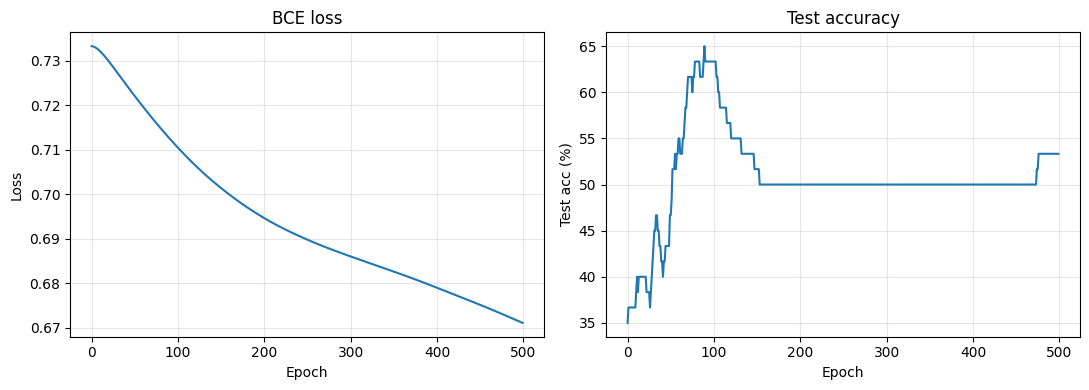

ANN final test accuracy: 53.33%
(Baseline LogReg đạt 41.67% — ANN thắng đậm vì học được ranh giới phi tuyến.)


In [24]:
#Phần 2: Loss và Optimizer
#Đổi BCELoss thành BCEWithLogitsLoss: bỏ nn.Sigmoid khỏi model (BCEWithLogitsLoss tự xử lý). Train 500 epoch. Lưu ý: khi predict cần torch.sigmoid(output) > 0.5 chứ không phải output > 0.5.
#Gợi ý: BCEWithLogitsLoss ổn định số học hơn vì gộp sigmoid + log thành một phép tính log(1 + exp(-x)) (log-sum-exp trick), tránh tràn số khi
# lớn.
#Đổi Adam thành SGD (lr = 0.01, momentum = 0.9). Train 500 epoch. So sánh tốc độ hội tụ với Adam.


class ANN(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(2, 4)
        self.relu   = nn.ReLU()
        self.layer2 = nn.Linear(4, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        return self.sigmoid(self.layer2(self.relu(self.layer1(x))))

model = ANN()
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01,momentum=0.9) #Đổi Adam thành SGD (lr = 0.01, momentum = 0.9). Train 500 epoch. So sánh tốc độ hội tụ với Adam.
print(model)
epochs = 500
loss_history, acc_history = [], []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        test_pred = (model(X_test) > 0.5).float()
        acc = (test_pred == y_test).float().mean().item()
    loss_history.append(loss.item())
    acc_history.append(acc)

    if (epoch + 1) % 100 == 0:
        print(f'Epoch {epoch+1:4d}/{epochs}  loss={loss.item():.4f}  test_acc={acc*100:.2f}%')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(loss_history); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].grid(alpha=0.3)
axes[0].set_title('BCE loss')
axes[1].plot([a*100 for a in acc_history]); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Test acc (%)'); axes[1].grid(alpha=0.3)
axes[1].set_title('Test accuracy')
plt.tight_layout(); plt.show()
model.eval()
with torch.no_grad():
    pred = (model(X_test) > 0.5).float()
    acc_ann = (pred == y_test).float().mean().item()
print(f'ANN final test accuracy: {acc_ann*100:.2f}%')
print(f'(Baseline LogReg đạt {acc_lr*100:.2f}% — ANN thắng đậm vì học được ranh giới phi tuyến.)')


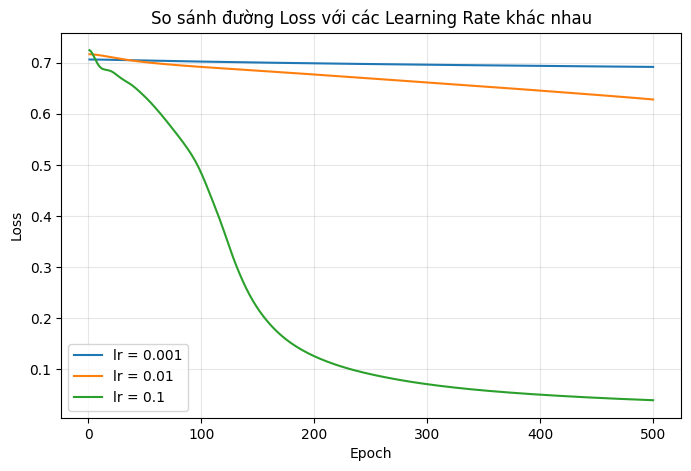

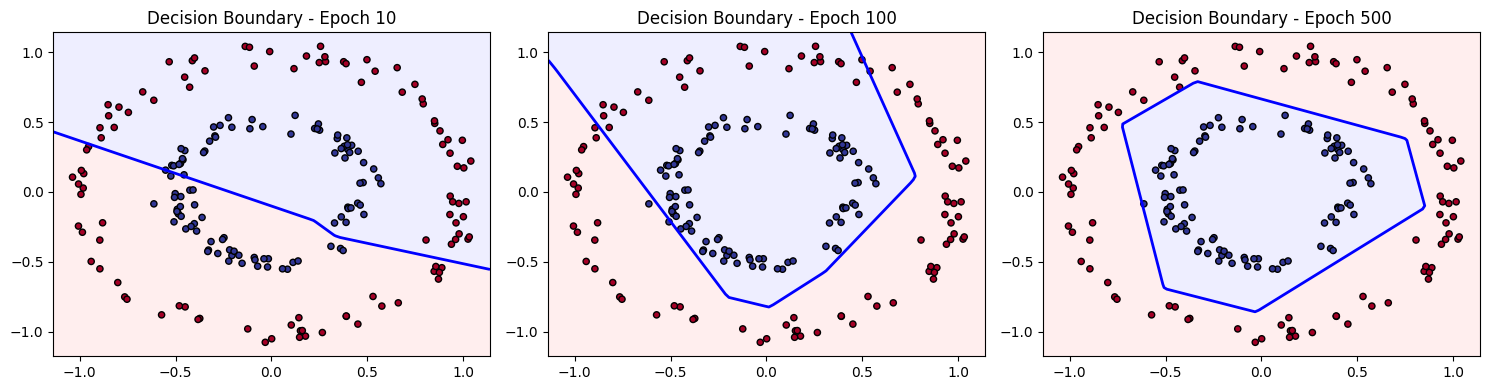

In [32]:
#Phần 3: Phân tích sâu
#Thử 3 learning rate: lr ∈ {0.001, 0.01, 0.1} với cấu trúc gốc. Vẽ 3 đường loss trên cùng đồ thị. Mô tả:

#lr nào quá nhỏ → học chậm?
#lr nào quá lớn → loss dao động hoặc nổ?
#Vẽ ranh giới quyết định ở các epoch 10, 100, 500. Em nên thấy boundary từ thẳng dần dần thành cong tròn.

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# Giả định dữ liệu phi tuyến dạng vòng tròn (Circles) hoặc tương tự để thấy Boundary cong tròn
# Nếu bạn đã có X_train, y_train, X_test, y_test từ trước, hãy bỏ qua phần tạo dữ liệu này.
from sklearn.datasets import make_circles
X, y = make_circles(n_samples=1000, noise=0.05, factor=0.5, random_state=42)
X_train = torch.FloatTensor(X[:800])
y_train = torch.FloatTensor(y[:800]).unsqueeze(1)
X_test = torch.FloatTensor(X[800:])
y_test = torch.FloatTensor(y[800:]).unsqueeze(1)

# Định nghĩa cấu trúc mạng gốc (Bỏ tầng Sigmoid cuối cùng vì dùng BCEWithLogitsLoss)
class ANN(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(2, 4)
        self.relu   = nn.ReLU()
        self.layer2 = nn.Linear(4, 1)

    def forward(self, x):
        return self.layer2(self.relu(self.layer1(x)))

# Hàm vẽ ranh giới quyết định (Decision Boundary)
def plot_decision_boundary(model, X, y, ax, title):
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    grid = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])

    model.eval()
    with torch.no_grad():
        # Dùng torch.sigmoid vì mô hình chỉ xuất ra logits
        preds = torch.sigmoid(model(grid)).reshape(xx.shape).numpy()

    ax.contourf(xx, yy, preds, levels=[0, 0.5, 1], alpha=0.2, colors=['#FFAAAA', '#AAAAFF'])
    ax.contour(xx, yy, preds, levels=[0.5], colors='blue', linewidths=2)
    ax.scatter(X[:, 0], X[:, 1], c=y.ravel(), cmap=plt.cm.RdYlBu, edgecolors='k', s=20)
    ax.set_title(title)

# --- PHẦN 1: THỬ 3 LEARNING RATE VÀ VẼ LỊCH SỬ LOSS ---
learning_rates = [0.001, 0.01, 0.1]
epochs = 500
loss_histories = {}

for lr in learning_rates:
    model = ANN() # Tạo mô hình mới tinh cho mỗi lr
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)

    lr_losses = []
    for epoch in range(epochs):
        model.train()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        lr_losses.append(loss.item())
    loss_histories[lr] = lr_losses

# Vẽ 3 đường loss trên cùng đồ thị
plt.figure(figsize=(8, 5))
for lr in learning_rates:
    plt.plot(range(1, epochs + 1), loss_histories[lr], label=f'lr = {lr}')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('So sánh đường Loss với các Learning Rate khác nhau')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# --- PHẦN 2: QUAN SÁT RANH GIỚI QUYẾT ĐỊNH THEO EPOCH (Sử dụng lr tối ưu là 0.1) ---
model = ANN()
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
target_epochs = [10, 100, 500]
ax_idx = 0

for epoch in range(1, 501):
    model.train()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch in target_epochs:
        plot_decision_boundary(model, X_test.numpy(), y_test.numpy(), axes[ax_idx], f'Decision Boundary - Epoch {epoch}')
        ax_idx += 1

plt.tight_layout()
plt.show()